In [1]:
import polars as pl
from paths import ROOT_DIR, DATA_DIR

train_df = pl.read_ndjson(ROOT_DIR / "data/LibriSpeech-train-sim-100h/manifest.jsonl")

In [2]:
train_df["duration"].sum() / 60 / 60

106.09631999999996

In [3]:
train_df.head()

audio_filepath,text,language,condition,duration,sample_rate,utterance_id
str,str,str,str,f64,i64,str
"""audio/good/1963-142776-0012.wa…","""OR SIX SMALL ONES THE CRUMB OF…","""en""","""good""",9.72,16000,"""1963-142776-0012"""
"""audio/good/8095-274346-0005.wa…","""THEY PETITIONED THE KING FOR R…","""en""","""good""",15.635,16000,"""8095-274346-0005"""
"""audio/okay/3857-182317-0031.wa…","""BACK OF IT THERE MUST BE SOME …","""en""","""okay""",12.795,16000,"""3857-182317-0031"""
"""audio/perfect/87-121553-0044.w…","""AND IF IT DO REMAIN SAY IN WHA…","""en""","""perfect""",14.915,16000,"""87-121553-0044"""
"""audio/good/911-128684-0053.wav""","""INTO THE WATER WHICH IT SETS A…","""en""","""good""",14.555,16000,"""911-128684-0053"""


In [4]:
train_df.filter(pl.col("utterance_id") == "1963-142776-0012")

audio_filepath,text,language,condition,duration,sample_rate,utterance_id
str,str,str,str,f64,i64,str
"""audio/good/1963-142776-0012.wa…","""OR SIX SMALL ONES THE CRUMB OF…","""en""","""good""",9.72,16000,"""1963-142776-0012"""
"""audio/perfect/1963-142776-0012…","""OR SIX SMALL ONES THE CRUMB OF…","""en""","""perfect""",9.72,16000,"""1963-142776-0012"""


In [5]:
audio_path = "LibriSpeech-test-other-sint/audio/{condition}/367-293981-0010.wav"

paths = [
    DATA_DIR / audio_path.format(condition=condition)
    for condition in ["perfect", "good", "okay", "bad"]
]

In [6]:
import soundfile as sf

audios = [sf.read(path) for path in paths]
conditions = ["real", "perfect", "good", "okay", "bad"]

In [7]:
gt_audio = sf.read(
    DATA_DIR / "LibriSpeech-test-other/test-other/367/293981/367-293981-0010.flac"
)

In [8]:
audios = [gt_audio] + audios

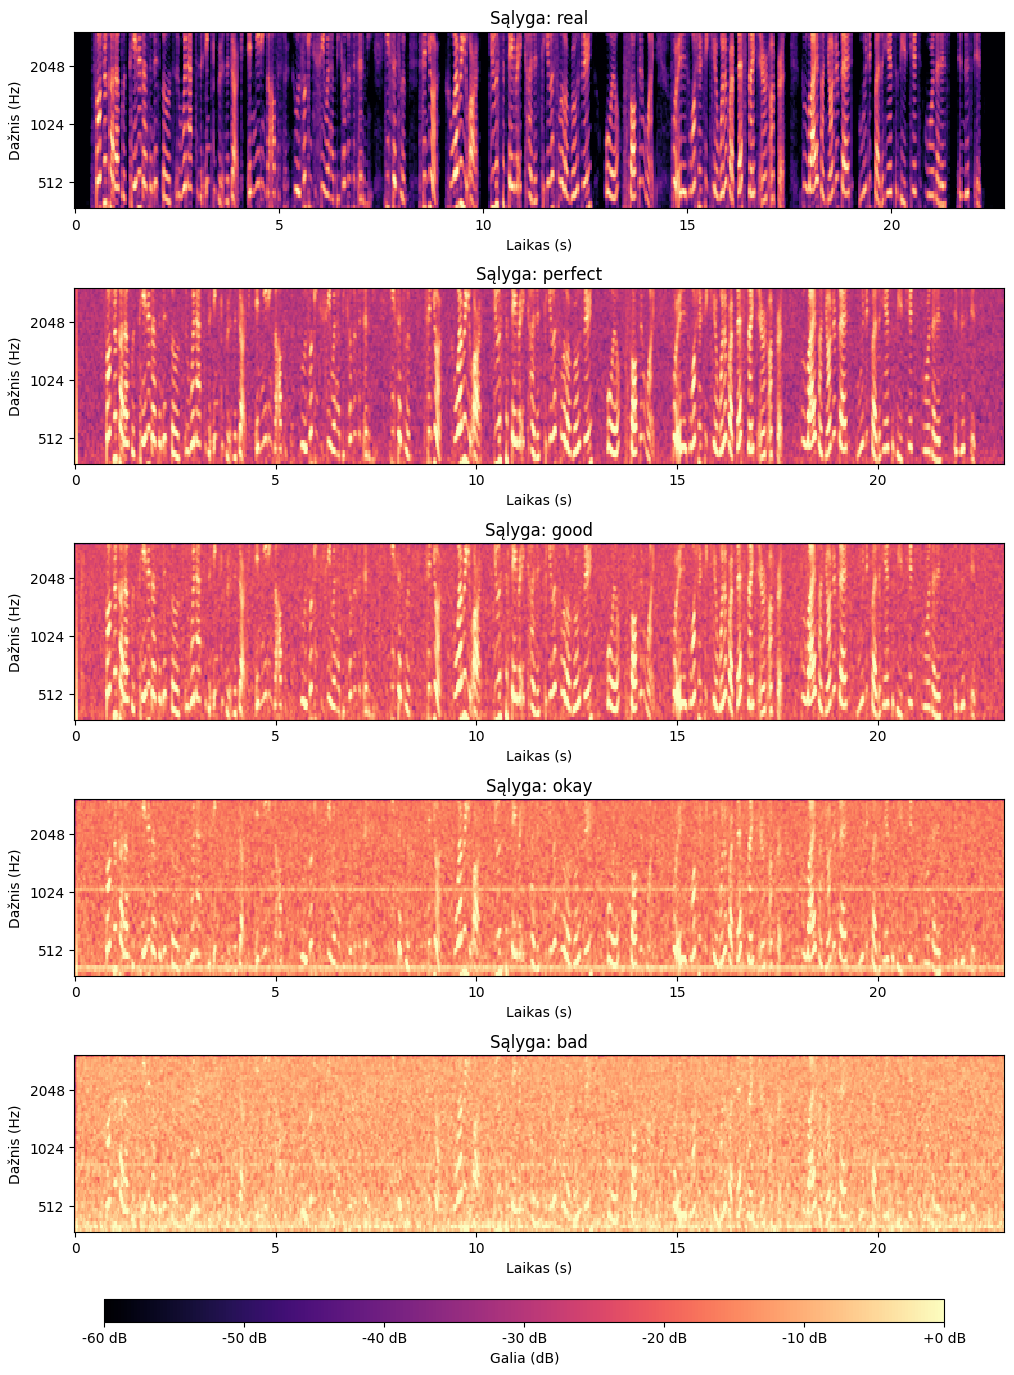

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

FMIN = 300
FMAX = 3400
N_MELS = 64
SR = 16_000


mel_specs = []
for (audio, sr), condition in zip(audios, conditions):
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
    )

    mel_specs.append(mel)


all_power = np.concatenate([m.flatten() for m in mel_specs])
ref_val = float(np.percentile(all_power, 99))

mel_specs_db = [librosa.power_to_db(m, ref=ref_val) for m in mel_specs]


vmax = 0.0
vmin = -60.0


fig, axes = plt.subplots(
    len(conditions),
    1,
    figsize=(12, 3 * len(conditions)),
)

for i, ((audio, sr), condition, mel_db) in enumerate(
    zip(audios, conditions, mel_specs_db)
):
    img = librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        ax=axes[i],
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
    )

    ymin, ymax = axes[i].get_ylim()
    axes[i].set_ylim(ymin, ymax * 0.90)

    axes[i].set_title(f"Sąlyga: {condition}")
    axes[i].set_xlabel("Laikas (s)")
    axes[i].set_ylabel("Dažnis (Hz)")


fig.subplots_adjust(bottom=0.08, hspace=0.45)

cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.015])

cbar = fig.colorbar(
    img,
    cax=cbar_ax,
    orientation="horizontal",
    format="%+2.0f dB",
)

cbar.set_label(
    "Galia (dB)",
    labelpad=4,
)

plt.show()

  perfect: 20 files
  good: 20 files
  okay: 20 files
  bad: 20 files
  clean: 20 files


Extracting features:   0%|          | 0/100 [00:00<?, ?it/s]

Features cached → features_cache.pkl
  100 utterances × 64 mel features


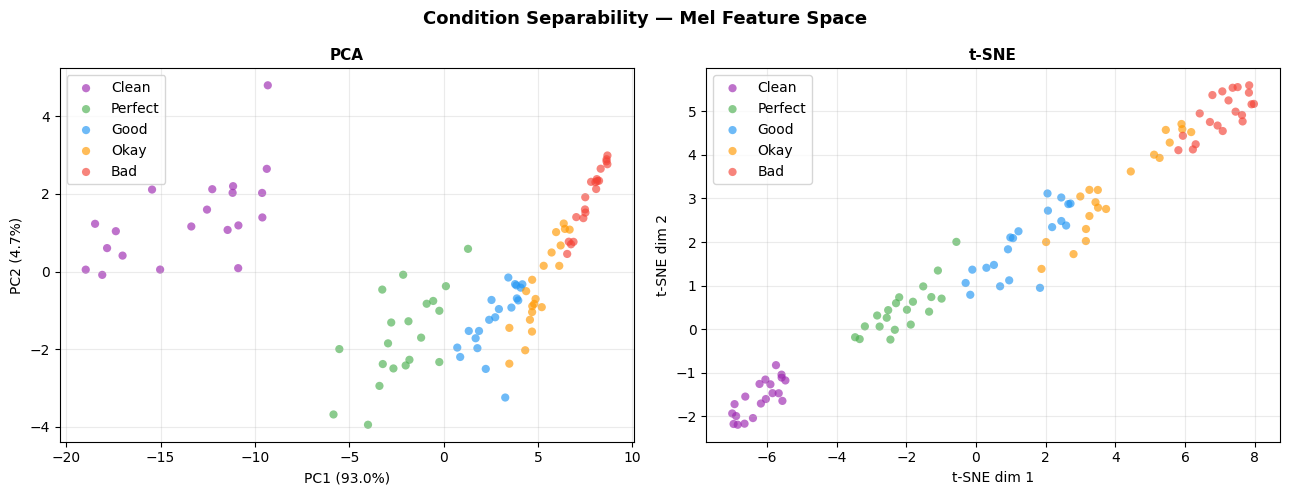

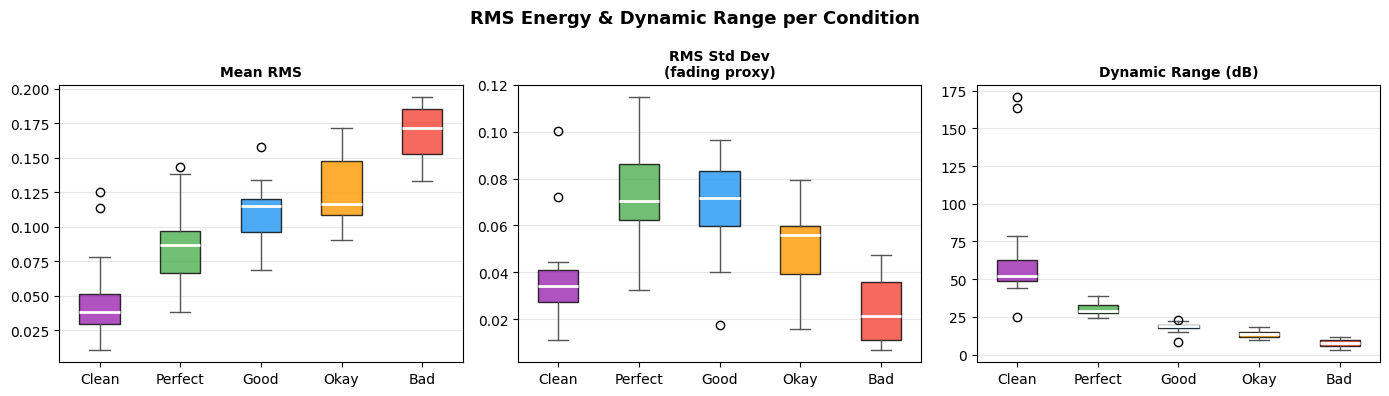

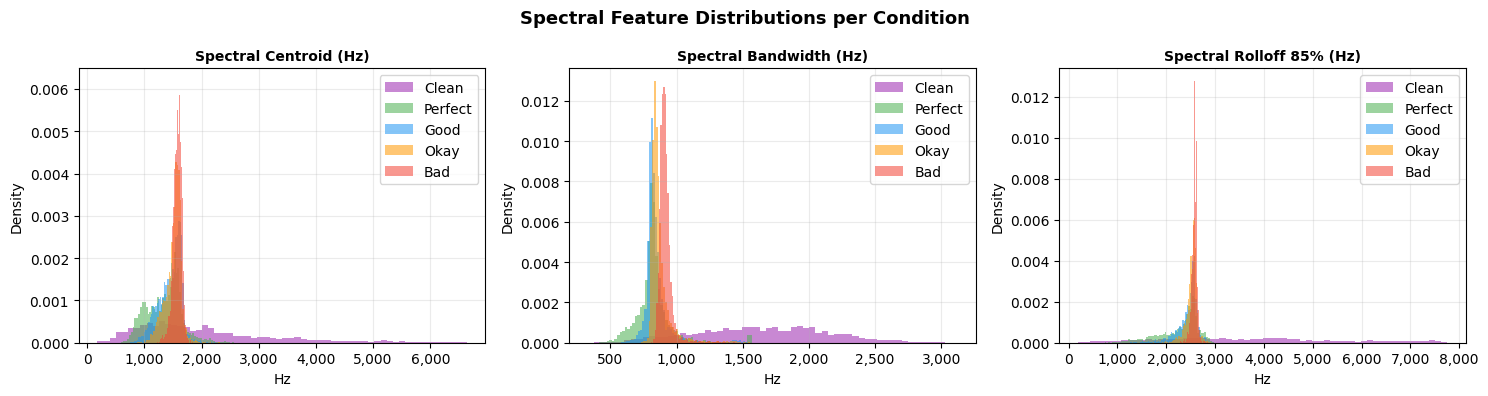

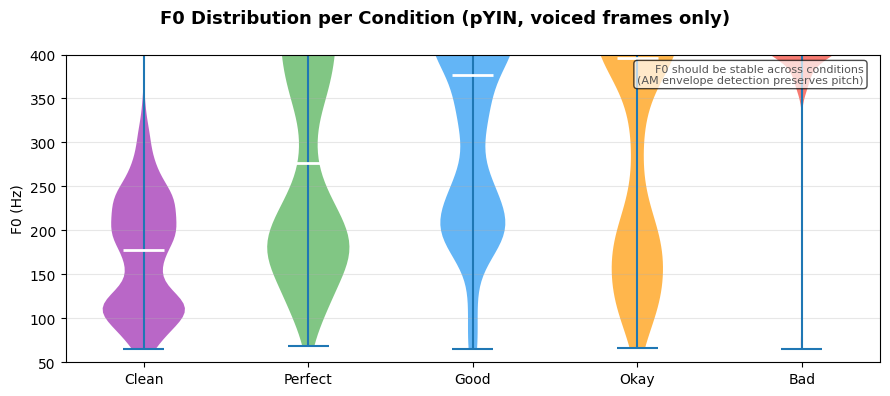

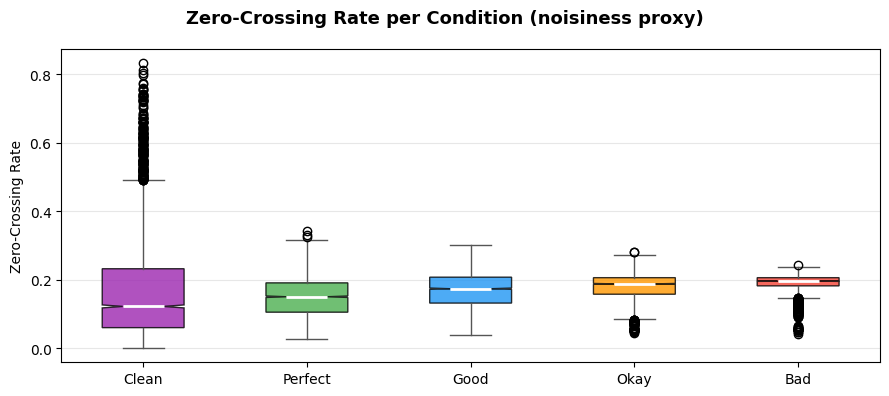

All plots saved to analysis_plots/


In [10]:
import json
import random
import warnings
import pickle
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

import librosa
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)


SR = 16_000
FMIN = 300
FMAX = 3_400
N_MELS = 64
HOP = 512
N_FFT = 2048
N_WORKERS = 8  # tune to your CPU count

CONDITIONS = ["clean", "perfect", "good", "okay", "bad"]
COND_COLORS = {
    "clean": "#9C27B0",
    "perfect": "#4CAF50",
    "good": "#2196F3",
    "okay": "#FF9800",
    "bad": "#F44336",
}


def load_manifest(
    jsonl_path: Path,
    data_root: Path,
    librispeech_root: Path,
    subset: int | None = None,
    seed: int = 42,
) -> dict[str, list[Path]]:
    manifest = {c: [] for c in CONDITIONS if c != "clean"}
    utt_ids = []  # preserve order for clean path construction

    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            entry = json.loads(line)
            cond = entry["condition"]
            utt = entry["utterance_id"]  # e.g. "1688-142285-0002"
            if cond in manifest:
                manifest[cond].append(data_root / entry["audio_filepath"])
            if cond == "perfect":  # collect utt_ids once
                utt_ids.append(utt)

    clean_paths = []
    missing = 0
    for utt in utt_ids:
        parts = utt.split("-")  # ["1688", "142285", "0002"]
        speaker, chapter = parts[0], parts[1]
        flac = librispeech_root / speaker / chapter / f"{utt}.flac"
        if flac.exists():
            clean_paths.append(flac)
        else:
            missing += 1

    if missing:
        print(f"[WARN] {missing} clean FLAC files not found — check librispeech_root")

    manifest["clean"] = clean_paths

    if subset is not None:
        rng = random.Random(seed)
        manifest = {
            c: rng.sample(paths, min(subset, len(paths)))
            for c, paths in manifest.items()
        }

    return manifest


def extract_features(path: Path) -> dict:
    audio, _ = librosa.load(path, sr=SR, mono=True)

    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP, fmin=FMIN, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=1.0)

    rms = librosa.feature.rms(y=audio, hop_length=HOP)[0]
    centroid = librosa.feature.spectral_centroid(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP
    )[0]
    bandwidth = librosa.feature.spectral_bandwidth(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP
    )[0]
    rolloff = librosa.feature.spectral_rolloff(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP, roll_percent=0.85
    )[0]
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=HOP)[0]

    f0, voiced_flag, _ = librosa.pyin(
        audio,
        sr=SR,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        hop_length=HOP,
    )
    f0_voiced = f0[voiced_flag] if voiced_flag is not None else f0[~np.isnan(f0)]

    return {
        "mel_mean": mel_db.mean(axis=1),
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "dyn_range": float(20 * np.log10((rms.max() + 1e-9) / (rms.min() + 1e-9))),
        "centroid": centroid,
        "bandwidth": bandwidth,
        "rolloff": rolloff,
        "zcr": zcr,
        "f0": f0_voiced,
    }


def collect_dataset(
    manifest: dict[str, list[Path]],
    cache_path: Path | None = Path("features_cache.pkl"),
    workers: int = N_WORKERS,
) -> tuple[dict, np.ndarray, list[str]]:
    if cache_path and cache_path.exists():
        print(f"Loading cached features from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    tasks = [(path, cond) for cond in CONDITIONS for path in manifest[cond]]

    per_cond: dict[str, list[dict]] = {c: [] for c in CONDITIONS}
    results: dict[Path, dict] = {}

    with ThreadPoolExecutor(max_workers=workers) as pool:
        future_to_task = {
            pool.submit(extract_features, path): (path, cond) for path, cond in tasks
        }
        for future in tqdm(
            as_completed(future_to_task), total=len(tasks), desc="Extracting features"
        ):
            path, cond = future_to_task[future]
            try:
                results[(path, cond)] = future.result()
            except Exception as e:
                print(f"[SKIP] {path.name}: {e}")

    mel_rows, labels = [], []
    for path, cond in tasks:
        if (path, cond) in results:
            feats = results[(path, cond)]
            per_cond[cond].append(feats)
            mel_rows.append(feats["mel_mean"])
            labels.append(cond)

    out = (per_cond, np.vstack(mel_rows), labels)

    if cache_path:
        with open(cache_path, "wb") as f:
            pickle.dump(out, f)
        print(f"Features cached → {cache_path}")

    return out


def plot_pca_tsne(mel_matrix, labels, out):
    X = StandardScaler().fit_transform(mel_matrix)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    X_tsne = TSNE(
        n_components=2, perplexity=30, random_state=42, max_iter=1000, init="pca"
    ).fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Condition Separability — Mel Feature Space", fontsize=13, fontweight="bold"
    )
    for ax, X_emb, title, (xl, yl) in zip(
        axes,
        [X_pca, X_tsne],
        ["PCA", "t-SNE"],
        [
            (
                f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
                f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
            ),
            ("t-SNE dim 1", "t-SNE dim 2"),
        ],
    ):
        for cond in CONDITIONS:
            idx = [i for i, l in enumerate(labels) if l == cond]
            ax.scatter(
                X_emb[idx, 0],
                X_emb[idx, 1],
                c=COND_COLORS[cond],
                label=cond.capitalize(),
                alpha=0.65,
                s=35,
                edgecolors="none",
            )
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.legend(framealpha=0.8)
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_rms_dynrange(per_cond, out):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        "RMS Energy & Dynamic Range per Condition", fontsize=13, fontweight="bold"
    )
    for ax, key, title in zip(
        axes,
        ["rms_mean", "rms_std", "dyn_range"],
        ["Mean RMS", "RMS Std Dev\n(fading proxy)", "Dynamic Range (dB)"],
    ):
        data = [np.array([f[key] for f in per_cond[c]]) for c in CONDITIONS]
        bp = ax.boxplot(
            data,
            patch_artist=True,
            widths=0.5,
            medianprops={"color": "white", "linewidth": 2},
        )
        for patch, color in zip(bp["boxes"], [COND_COLORS[c] for c in CONDITIONS]):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        for el in ["whiskers", "caps", "fliers"]:
            for item in bp[el]:
                item.set_color("#555")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xticks(range(1, len(CONDITIONS) + 1))
        ax.set_xticklabels([c.capitalize() for c in CONDITIONS])
        ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_spectral(per_cond, out):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        "Spectral Feature Distributions per Condition", fontsize=13, fontweight="bold"
    )
    for ax, key, title in zip(
        axes,
        ["centroid", "bandwidth", "rolloff"],
        [
            "Spectral Centroid (Hz)",
            "Spectral Bandwidth (Hz)",
            "Spectral Rolloff 85% (Hz)",
        ],
    ):
        for cond in CONDITIONS:
            vals = np.concatenate([f[key] for f in per_cond[cond]])
            vals = vals[(vals > 0) & np.isfinite(vals)]
            ax.hist(
                vals,
                bins=60,
                alpha=0.55,
                color=COND_COLORS[cond],
                label=cond.capitalize(),
                density=True,
            )
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Hz")
        ax.set_ylabel("Density")
        ax.legend(framealpha=0.8)
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_f0(per_cond, out):
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.suptitle(
        "F0 Distribution per Condition (pYIN, voiced frames only)",
        fontsize=13,
        fontweight="bold",
    )
    data = [
        np.concatenate([f["f0"] for f in per_cond[c] if len(f["f0"]) > 0])
        for c in CONDITIONS
    ]
    bp = ax.violinplot(data, positions=range(len(CONDITIONS)), showmedians=True)
    for body, color in zip(bp["bodies"], [COND_COLORS[c] for c in CONDITIONS]):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    bp["cmedians"].set_color("white")
    bp["cmedians"].set_linewidth(2)
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([c.capitalize() for c in CONDITIONS])
    ax.set_ylabel("F0 (Hz)")
    ax.set_ylim(50, 400)
    ax.grid(True, axis="y", alpha=0.3)
    ax.text(
        0.98,
        0.97,
        "F0 should be stable across conditions\n(AM envelope detection preserves pitch)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="#555",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
    )
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_zcr(per_cond, out):
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.suptitle(
        "Zero-Crossing Rate per Condition (noisiness proxy)",
        fontsize=13,
        fontweight="bold",
    )
    data = [np.concatenate([f["zcr"] for f in per_cond[c]]) for c in CONDITIONS]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        notch=True,
        medianprops={"color": "white", "linewidth": 2},
    )
    for patch, color in zip(bp["boxes"], [COND_COLORS[c] for c in CONDITIONS]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    for el in ["whiskers", "caps"]:
        for item in bp[el]:
            item.set_color("#555")
    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels([c.capitalize() for c in CONDITIONS])
    ax.set_ylabel("Zero-Crossing Rate")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def run_analysis(
    manifest, output_dir=Path("analysis_plots"), cache_path=Path("features_cache.pkl")
):
    output_dir.mkdir(parents=True, exist_ok=True)
    per_cond, mel_matrix, labels = collect_dataset(manifest, cache_path=cache_path)
    print(f"  {len(labels)} utterances × {mel_matrix.shape[1]} mel features")

    plot_pca_tsne(mel_matrix, labels, output_dir / "01_pca_tsne.png")
    plot_rms_dynrange(per_cond, output_dir / "02_rms_dynrange.png")
    plot_spectral(per_cond, output_dir / "03_spectral.png")
    plot_f0(per_cond, output_dir / "04_f0.png")
    plot_zcr(per_cond, output_dir / "05_zcr.png")
    print(f"All plots saved to {output_dir}/")


DATA_ROOT = DATA_DIR / "LibriSpeech-test-other-sint"
MANIFEST_PATH = DATA_ROOT / "manifest.jsonl"
LIBRISPEECH_ROOT = DATA_DIR / "LibriSpeech-test-other/test-other"

manifest = load_manifest(
    MANIFEST_PATH,
    DATA_ROOT,
    librispeech_root=LIBRISPEECH_ROOT,
    subset=20,
)
for cond, paths in manifest.items():
    print(f"  {cond}: {len(paths)} files")

import os

cache = Path("features_cache.pkl")
if cache.exists():
    os.remove(cache)
    print("Cache cleared — conditions changed")

run_analysis(manifest)

In [14]:
import warnings
import os
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)


SR = 16_000
FMIN = 300
FMAX = 3_400
N_MELS = 64
HOP = 512
N_FFT = 2048
N_WORKERS = 8


CONDITIONS: list[str] = []
COND_COLORS: dict[str, str] = {}


def load_librispeech_manifest(
    jsonl_path: Path,
    data_root: Path,
    librispeech_root: Path,
    subset: int | None = None,
    seed: int = 42,
) -> dict[str, list[Path]]:
    sim_conds = {"perfect", "good", "okay", "bad"}

    utt_to_paths: dict[str, dict[str, Path]] = {}
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            entry = json.loads(line)
            cond, utt = entry["condition"], entry["utterance_id"]
            if cond not in sim_conds:
                continue
            utt_to_paths.setdefault(utt, {})[cond] = data_root / entry["audio_filepath"]

    complete_utts = [u for u, c in utt_to_paths.items() if sim_conds.issubset(c)]

    if subset is not None:
        rng = random.Random(seed)
        complete_utts = rng.sample(complete_utts, min(subset, len(complete_utts)))

    valid_utts, missing = [], 0
    for utt in complete_utts:
        speaker, chapter = utt.split("-")[:2]
        flac = librispeech_root / speaker / chapter / f"{utt}.flac"
        if flac.exists():
            valid_utts.append(utt)
        else:
            missing += 1

    if missing:
        print(f"[WARN] {missing} clean FLACs not found — dropped")

    manifest: dict[str, list[Path]] = {c: [] for c in ["clean"] + sorted(sim_conds)}
    for utt in valid_utts:
        speaker, chapter = utt.split("-")[:2]
        manifest["clean"].append(librispeech_root / speaker / chapter / f"{utt}.flac")
        for cond in sim_conds:
            manifest[cond].append(utt_to_paths[utt][cond])

    return manifest


def load_atc_manifest(
    jsonl_path: Path, data_root: Path, subset: int | None = None, seed: int = 42
) -> list[Path]:
    paths = []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            entry = json.loads(line)
            p = data_root / entry["audio_filepath"]
            if p.exists():
                paths.append(p)

    if subset is not None:
        rng = random.Random(seed)
        paths = rng.sample(paths, min(subset, len(paths)))

    return paths


def extract_features(path: Path) -> dict:
    audio, _ = librosa.load(path, sr=SR, mono=True)

    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP, fmin=FMIN, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=1.0)

    rms = librosa.feature.rms(y=audio, hop_length=HOP)[0]
    centroid = librosa.feature.spectral_centroid(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP
    )[0]
    bandwidth = librosa.feature.spectral_bandwidth(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP
    )[0]
    rolloff = librosa.feature.spectral_rolloff(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP, roll_percent=0.85
    )[0]
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=HOP)[0]

    f0, voiced_flag, _ = librosa.pyin(
        audio,
        sr=SR,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        hop_length=HOP,
    )
    f0_voiced = f0[voiced_flag] if voiced_flag is not None else f0[~np.isnan(f0)]

    return {
        "mel_mean": mel_db.mean(axis=1),
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "dyn_range": float(20 * np.log10((rms.max() + 1e-9) / (rms.min() + 1e-9))),
        "centroid": centroid,
        "bandwidth": bandwidth,
        "rolloff": rolloff,
        "zcr": zcr,
        "f0": f0_voiced,
    }


def collect_dataset(
    manifest: dict[str, list[Path]],
    cache_path: Path | None = Path("features_cache.pkl"),
    workers: int = N_WORKERS,
) -> tuple[dict, np.ndarray, list[str]]:
    if cache_path and cache_path.exists():
        print(f"Loading cached features from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    tasks = [(path, cond) for cond in CONDITIONS for path in manifest[cond]]

    print(f"Total tasks: {len(tasks)}")

    results: dict = {}
    errors: list = []

    with ThreadPoolExecutor(max_workers=workers) as pool:
        future_to_task = {
            pool.submit(extract_features, path): (path, cond) for path, cond in tasks
        }
        for future in tqdm(
            as_completed(future_to_task), total=len(tasks), desc="Extracting features"
        ):
            path, cond = future_to_task[future]
            try:
                results[(path, cond)] = future.result()
            except Exception as e:
                errors.append((path.name, str(e)))

    if errors:
        print(f"\n[ERRORS] {len(errors)} failed:")
        for name, err in errors[:10]:
            print(f"  {name}: {err}")

    per_cond: dict[str, list[dict]] = {c: [] for c in CONDITIONS}
    mel_rows, labels = [], []
    for path, cond in tasks:
        if (path, cond) in results:
            feats = results[(path, cond)]
            per_cond[cond].append(feats)
            mel_rows.append(feats["mel_mean"])
            labels.append(cond)

    print(f"\nSuccessful: {len(mel_rows)} / {len(tasks)}")
    for cond in CONDITIONS:
        print(f"  {cond}: {len(per_cond[cond])}")

    if not mel_rows:
        raise RuntimeError("No features extracted — check errors above")

    out = (per_cond, np.vstack(mel_rows), labels)

    if cache_path:
        with open(cache_path, "wb") as f:
            pickle.dump(out, f)
        print(f"Cached → {cache_path}")

    return out


def plot_pca_tsne(mel_matrix, labels, out):
    X = StandardScaler().fit_transform(mel_matrix)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    X_tsne = TSNE(
        n_components=2,
        perplexity=min(30, len(labels) // 2),
        random_state=42,
        max_iter=1000,
        init="pca",
    ).fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Condition Separability — Mel Feature Space", fontsize=13, fontweight="bold"
    )

    for ax, X_emb, title, (xl, yl) in zip(
        axes,
        [X_pca, X_tsne],
        ["PCA", "t-SNE"],
        [
            (
                f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
                f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
            ),
            ("t-SNE dim 1", "t-SNE dim 2"),
        ],
    ):
        for cond in CONDITIONS:
            idx = [i for i, l in enumerate(labels) if l == cond]
            ax.scatter(
                X_emb[idx, 0],
                X_emb[idx, 1],
                c=COND_COLORS[cond],
                label=cond.replace("_", " ").capitalize(),
                alpha=0.65,
                s=40,
                edgecolors="none",
            )
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.legend(framealpha=0.8)
        ax.grid(True, alpha=0.25)

    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_rms_dynrange(per_cond, out):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        "RMS Energy & Dynamic Range per Condition", fontsize=13, fontweight="bold"
    )

    for ax, key, title in zip(
        axes,
        ["rms_mean", "rms_std", "dyn_range"],
        ["Mean RMS", "RMS Std Dev\n(fading proxy)", "Dynamic Range (dB)"],
    ):
        data = [np.array([f[key] for f in per_cond[c]]) for c in CONDITIONS]
        bp = ax.boxplot(
            data,
            patch_artist=True,
            widths=0.5,
            medianprops={"color": "white", "linewidth": 2},
        )
        for patch, color in zip(bp["boxes"], [COND_COLORS[c] for c in CONDITIONS]):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        for el in ["whiskers", "caps", "fliers"]:
            for item in bp[el]:
                item.set_color("#555")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xticks(range(1, len(CONDITIONS) + 1))
        ax.set_xticklabels(
            [c.replace("_", " ").capitalize() for c in CONDITIONS],
            rotation=15,
            ha="right",
        )
        ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_spectral(per_cond, out):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        "Spectral Feature Distributions per Condition", fontsize=13, fontweight="bold"
    )

    for ax, key, title in zip(
        axes,
        ["centroid", "bandwidth", "rolloff"],
        [
            "Spectral Centroid (Hz)",
            "Spectral Bandwidth (Hz)",
            "Spectral Rolloff 85% (Hz)",
        ],
    ):
        for cond in CONDITIONS:
            vals = np.concatenate([f[key] for f in per_cond[cond]])
            vals = vals[(vals > 0) & np.isfinite(vals)]
            ax.hist(
                vals,
                bins=60,
                alpha=0.55,
                color=COND_COLORS[cond],
                label=cond.replace("_", " ").capitalize(),
                density=True,
            )
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Hz")
        ax.set_ylabel("Density")
        ax.legend(framealpha=0.8)
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_f0(per_cond, out):
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle(
        "F0 Distribution per Condition (pYIN, voiced frames only)",
        fontsize=13,
        fontweight="bold",
    )

    data = [
        np.concatenate([f["f0"] for f in per_cond[c] if len(f["f0"]) > 0])
        for c in CONDITIONS
    ]
    bp = ax.violinplot(data, positions=range(len(CONDITIONS)), showmedians=True)
    for body, color in zip(bp["bodies"], [COND_COLORS[c] for c in CONDITIONS]):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    bp["cmedians"].set_color("white")
    bp["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels(
        [c.replace("_", " ").capitalize() for c in CONDITIONS], rotation=15, ha="right"
    )
    ax.set_ylabel("F0 (Hz)")
    ax.set_ylim(50, 400)
    ax.grid(True, axis="y", alpha=0.3)
    ax.text(
        0.98,
        0.97,
        "F0 should be stable across simulated conditions\n"
        "Real ATC may differ due to radio characteristics",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="#555",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
    )

    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def plot_zcr(per_cond, out):
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle(
        "Zero-Crossing Rate per Condition (noisiness proxy)",
        fontsize=13,
        fontweight="bold",
    )

    data = [np.concatenate([f["zcr"] for f in per_cond[c]]) for c in CONDITIONS]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        notch=True,
        medianprops={"color": "white", "linewidth": 2},
    )
    for patch, color in zip(bp["boxes"], [COND_COLORS[c] for c in CONDITIONS]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    for el in ["whiskers", "caps"]:
        for item in bp[el]:
            item.set_color("#555")

    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(
        [c.replace("_", " ").capitalize() for c in CONDITIONS], rotation=15, ha="right"
    )
    ax.set_ylabel("Zero-Crossing Rate")
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


def run_analysis(
    manifest, output_dir=Path("analysis_plots"), cache_path=Path("features_cache.pkl")
):
    output_dir.mkdir(parents=True, exist_ok=True)
    per_cond, mel_matrix, labels = collect_dataset(manifest, cache_path=cache_path)
    print(f"  {len(labels)} utterances × {mel_matrix.shape[1]} mel features")

    plot_pca_tsne(mel_matrix, labels, output_dir / "01_pca_tsne.png")
    plot_rms_dynrange(per_cond, output_dir / "02_rms_dynrange.png")
    plot_spectral(per_cond, output_dir / "03_spectral.png")
    plot_f0(per_cond, output_dir / "04_f0.png")
    plot_zcr(per_cond, output_dir / "05_zcr.png")
    print(f"All plots saved to {output_dir}/")


DATA_ROOT = DATA_DIR / "LibriSpeech-test-clean-sint"
MANIFEST_PATH = DATA_ROOT / "manifest.jsonl"
LIBRISPEECH_ROOT = DATA_DIR / "LibriSpeech-test-clean/test-clean"
ATC_ROOT = DATA_DIR / "atc_asr_train"
ATC_MANIFEST = ATC_ROOT / "manifest.jsonl"

SUBSET = 100

atc_paths = load_atc_manifest(ATC_MANIFEST, ATC_ROOT, subset=SUBSET)
manifest = load_librispeech_manifest(
    MANIFEST_PATH,
    DATA_ROOT,
    librispeech_root=LIBRISPEECH_ROOT,
    subset=SUBSET,
)
manifest["real_atc"] = atc_paths

CONDITIONS = ["clean", "perfect", "good", "okay", "bad", "real_atc"]
COND_COLORS = {
    "clean": "#9C27B0",
    "perfect": "#4CAF50",
    "good": "#2196F3",
    "okay": "#FF9800",
    "bad": "#F44336",
    "real_atc": "#795548",
}

for cond, paths in manifest.items():
    exists = sum(p.exists() for p in paths)
    print(f"  {cond}: {len(paths)} files, {exists} on disk")

cache = Path("features_cache.pkl")
if cache.exists():
    os.remove(cache)
    print("Cache cleared")

run_analysis(manifest)

  clean: 100 files, 100 on disk
  bad: 100 files, 100 on disk
  good: 100 files, 100 on disk
  okay: 100 files, 100 on disk
  perfect: 100 files, 100 on disk
  real_atc: 0 files, 0 on disk
Cache cleared
Total tasks: 500


Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]


KeyboardInterrupt



KeyboardInterrupt: 

In [1]:
from pathlib import Path
from paths import ROOT_DIR

for manifest in [
    "data/LibriSpeech-train-final-with-atc/manifest.jsonl",
    "data/LibriSpeech-dev-combined-with-atc/manifest.jsonl",
    "data/LibriSpeech-test-combined-with-atc/manifest.jsonl",
]:
    path = ROOT_DIR / manifest
    lines = path.read_text().splitlines()
    kept, renamed, removed = [], 0, 0

    for line in lines:
        if not line.strip():
            continue
        row = json.loads(line)
        if "transcription" in row and "text" not in row:
            row["text"] = row.pop("transcription")
            renamed += 1
        if not str(row.get("text") or "").strip():
            removed += 1
            continue
        kept.append(json.dumps(row))

    path.write_text("\n".join(kept) + "\n")
    print(f"{manifest}: renamed={renamed}, removed={removed}, kept={len(kept)}")

data/LibriSpeech-train-final-with-atc/manifest.jsonl: renamed=0, removed=6641, kept=28345
data/LibriSpeech-dev-combined-with-atc/manifest.jsonl: renamed=0, removed=812, kept=22268
data/LibriSpeech-test-combined-with-atc/manifest.jsonl: renamed=0, removed=813, kept=22236


In [3]:
import json
from pathlib import Path

for manifest in [
    ROOT_DIR / "data/LibriSpeech-train-final-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-dev-combined-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-test-combined-with-atc/manifest.jsonl",
]:
    with open(manifest) as f:
        keys = set()
        for line in f:
            if line.strip():
                keys.update(json.loads(line).keys())
    print(f"{manifest}: {keys}")

/home/ezka/vhf-bak/data/LibriSpeech-train-final-with-atc/manifest.jsonl: {'text', 'language', 'duration', 'utterance_id', 'condition', 'audio_filepath', 'sample_rate'}
/home/ezka/vhf-bak/data/LibriSpeech-dev-combined-with-atc/manifest.jsonl: {'text', 'language', 'duration', 'utterance_id', 'condition', 'audio_filepath', 'sample_rate'}
/home/ezka/vhf-bak/data/LibriSpeech-test-combined-with-atc/manifest.jsonl: {'text', 'language', 'duration', 'utterance_id', 'condition', 'audio_filepath', 'sample_rate'}


In [4]:
import json

for manifest in [
    ROOT_DIR / "data/LibriSpeech-train-final-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-dev-combined-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-test-combined-with-atc/manifest.jsonl",
]:
    with open(manifest) as f:
        for i, line in enumerate(f):
            if line.strip():
                print(f"{manifest} sample:")
                print(json.loads(line))
                break

/home/ezka/vhf-bak/data/LibriSpeech-train-final-with-atc/manifest.jsonl sample:
{'audio_filepath': 'audio/perfect/8425-291444-0013.wav', 'text': 'THE INFANT YEARS OF OUR CITY TO INTRODUCE A THOUSAND PLEASING FICTIONS BUT I HAVE SCRUPULOUSLY DISCARDED MANY A PITHY TALE AND MARVELOUS ADVENTURE WHEREBY THE DROWSY EAR OF SUMMER INDOLENCE MIGHT BE ENTHRALLED', 'language': 'en', 'condition': 'perfect', 'duration': 15.895, 'sample_rate': 16000, 'utterance_id': '8425-291444-0013'}
/home/ezka/vhf-bak/data/LibriSpeech-dev-combined-with-atc/manifest.jsonl sample:
{'audio_filepath': 'audio/good/1272-128104-0014.wav', 'text': 'BY HARRY QUILTER M A', 'language': 'en', 'condition': 'good', 'duration': 2.245, 'sample_rate': 16000, 'utterance_id': '1272-128104-0014'}
/home/ezka/vhf-bak/data/LibriSpeech-test-combined-with-atc/manifest.jsonl sample:
{'audio_filepath': 'audio/good/1089-134686-0014.wav', 'text': 'HE TRIED TO THINK HOW IT COULD BE', 'language': 'en', 'condition': 'good', 'duration': 2.225, 

In [5]:
import json
from pathlib import Path

for manifest in [
    ROOT_DIR / "data/LibriSpeech-train-final-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-dev-combined-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-test-combined-with-atc/manifest.jsonl",
]:
    total, has_text, has_transcription, has_neither = 0, 0, 0, 0
    with open(manifest) as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            total += 1
            if str(row.get("text") or "").strip():
                has_text += 1
            elif str(row.get("transcription") or "").strip():
                has_transcription += 1
            else:
                has_neither += 1
    print(f"{manifest}")
    print(
        f"  total={total}, has_text={has_text}, has_transcription={has_transcription}, has_neither={has_neither}\n"
    )

/home/ezka/vhf-bak/data/LibriSpeech-train-final-with-atc/manifest.jsonl
  total=34986, has_text=28345, has_transcription=0, has_neither=6641

/home/ezka/vhf-bak/data/LibriSpeech-dev-combined-with-atc/manifest.jsonl
  total=23080, has_text=22268, has_transcription=0, has_neither=812

/home/ezka/vhf-bak/data/LibriSpeech-test-combined-with-atc/manifest.jsonl
  total=23049, has_text=22236, has_transcription=0, has_neither=813



In [6]:
import json

with open(ROOT_DIR / "data/LibriSpeech-train-final-with-atc/manifest.jsonl") as f:
    for line in f:
        if not line.strip():
            continue
        row = json.loads(line)
        if (
            not str(row.get("text") or "").strip()
            and not str(row.get("transcription") or "").strip()
        ):
            print(row)
            break

{'audio_filepath': 'audio/bad/2-103426-A-3.wav', 'text': '', 'language': 'en', 'condition': 'bad', 'duration': 5.0, 'sample_rate': 16000, 'utterance_id': '2-103426-A-3'}


In [7]:
import json

target_ids = {
    "00a81de9d20f87d04465",
    "00CRZ17A8RNXPWNUA6TD",
    "02BGH0IOBK840BNZBJS8",
    "02JXXZTPWNTYDOJSRZA0",
    "03O4GKWWJWGABTGDJZ0I",
    "040a3aae52e2afd996bf",
    "05G00R5Y52PDI47KAH8O",
    "069f14f140181c6e9a8c",
    "06WF9PTTMDBZIVCG3M6A",
    "07f194f9c1156d6d0a4e",
}

with open(ROOT_DIR / "data/LibriSpeech-test-combined-with-atc/manifest.jsonl") as f:
    for line in f:
        if not line.strip():
            continue
        row = json.loads(line)
        if row.get("utterance_id") in target_ids:
            print(row)

{'audio_filepath': 'audio/perfect/00a81de9d20f87d04465.wav', 'text': None, 'language': 'en', 'condition': 'perfect', 'duration': 1.51, 'sample_rate': 16000, 'utterance_id': '00a81de9d20f87d04465'}
{'audio_filepath': 'audio/perfect/00CRZ17A8RNXPWNUA6TD.wav', 'text': None, 'language': 'en', 'condition': 'perfect', 'duration': 1.9, 'sample_rate': 16000, 'utterance_id': '00CRZ17A8RNXPWNUA6TD'}
{'audio_filepath': 'audio/perfect/02BGH0IOBK840BNZBJS8.wav', 'text': None, 'language': 'en', 'condition': 'perfect', 'duration': 6.27, 'sample_rate': 16000, 'utterance_id': '02BGH0IOBK840BNZBJS8'}
{'audio_filepath': 'audio/perfect/02JXXZTPWNTYDOJSRZA0.wav', 'text': None, 'language': 'en', 'condition': 'perfect', 'duration': 1.03, 'sample_rate': 16000, 'utterance_id': '02JXXZTPWNTYDOJSRZA0'}
{'audio_filepath': 'audio/perfect/03O4GKWWJWGABTGDJZ0I.wav', 'text': None, 'language': 'en', 'condition': 'perfect', 'duration': 1.18, 'sample_rate': 16000, 'utterance_id': '03O4GKWWJWGABTGDJZ0I'}
{'audio_filepath

In [8]:
import json
from pathlib import Path

atc_lookup = {}
for atc_manifest in [
    ROOT_DIR / "data/atc_asr_train/manifest.jsonl",
    ROOT_DIR / "data/atc_asr_val/manifest.jsonl",
    ROOT_DIR / "data/atc_asr_test/manifest.jsonl",
]:
    path = Path(atc_manifest)
    if not path.exists():
        print(f"Missing: {atc_manifest}")
        continue
    with open(path) as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            uid = row.get("utterance_id")
            text = (row.get("text") or row.get("transcription") or "").strip().lower()
            if uid and text:
                atc_lookup[uid] = text

print(f"Loaded {len(atc_lookup):,} ATC transcriptions")

for manifest in [
    ROOT_DIR / "data/LibriSpeech-train-final-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-dev-combined-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-test-combined-with-atc/manifest.jsonl",
]:
    path = Path(manifest)
    kept, filled, missing = [], 0, 0

    with open(path) as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            text = str(row.get("text") or "").strip()
            if not text:
                uid = row.get("utterance_id")
                if uid in atc_lookup:
                    row["text"] = atc_lookup[uid]
                    filled += 1
                else:
                    missing += 1
                    continue  # drop if we can't find transcription
            kept.append(json.dumps(row))

    path.write_text("\n".join(kept) + "\n")
    print(f"{manifest}: filled={filled}, still_missing={missing}, kept={len(kept)}")

Loaded 8,122 ATC transcriptions
/home/ezka/vhf-bak/data/LibriSpeech-train-final-with-atc/manifest.jsonl: filled=6497, still_missing=144, kept=34842
/home/ezka/vhf-bak/data/LibriSpeech-dev-combined-with-atc/manifest.jsonl: filled=812, still_missing=0, kept=23080
/home/ezka/vhf-bak/data/LibriSpeech-test-combined-with-atc/manifest.jsonl: filled=813, still_missing=0, kept=23049


In [10]:
import json
from pathlib import Path

for manifest in [
    ROOT_DIR / "data/LibriSpeech-train-final-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-dev-combined-with-atc/manifest.jsonl",
    ROOT_DIR / "data/LibriSpeech-test-combined-with-atc/manifest.jsonl",
]:
    path = Path(manifest)
    updated, kept = 0, []

    with open(path) as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            if not str(row.get("text") or "").strip():
                row["text"] = ""
                updated += 1
            kept.append(json.dumps(row))

    path.write_text("\n".join(kept) + "\n")
    print(f"{manifest}: updated={updated}, total={len(kept)}")

/home/ezka/vhf-bak/data/LibriSpeech-train-final-with-atc/manifest.jsonl: updated=0, total=34842
/home/ezka/vhf-bak/data/LibriSpeech-dev-combined-with-atc/manifest.jsonl: updated=0, total=23080
/home/ezka/vhf-bak/data/LibriSpeech-test-combined-with-atc/manifest.jsonl: updated=0, total=23049
